# News NLP Pipeline Results Dashboard

This notebook visualizes existing outputs from the completed NLP pipeline and focuses on interpretation-ready presentation visuals.

## Setup And Imports

In [72]:
from pathlib import Path
import sys
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from wordcloud import WordCloud
import networkx as nx
import pyLDAvis
import pyLDAvis.gensim_models
from sklearn.metrics import ConfusionMatrixDisplay
import gensim
from gensim import corpora

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 13

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

preferred_inline_renderers = ['vscode', 'plotly_mimetype', 'notebook_connected', 'notebook']
available_renderers = set(pio.renderers)
selected_renderer = next((r for r in preferred_inline_renderers if r in available_renderers), None)
if selected_renderer is not None:
    pio.renderers.default = selected_renderer

## Load Existing Pipeline Outputs

In [73]:
processed_path = PROJECT_ROOT / 'data' / 'processed' / 'processed_nlp_features.parquet'
network_path = PROJECT_ROOT / 'data' / 'processed' / 'entity_network.json'
topic_map_path = PROJECT_ROOT / 'data' / 'topic_mapping.json'
model_path = PROJECT_ROOT / 'models' / 'lda_topic_model.gensim'
dictionary_path = PROJECT_ROOT / 'models' / 'corpus_dictionary.gensim'

df = pd.read_parquet(processed_path)
with open(network_path, 'r', encoding='utf-8') as f:
    network_data = json.load(f)
with open(topic_map_path, 'r', encoding='utf-8') as f:
    topic_mapping = {int(k): v for k, v in json.load(f).items()}

df['published_at'] = pd.to_datetime(df['published_at'], errors='coerce')
df['topic_name'] = df['dominant_topic'].map(topic_mapping).fillna('General News')

if df['extracted_entities'].dtype == 'object':
    def _ensure_list(v):
        if isinstance(v, list):
            return v
        if isinstance(v, np.ndarray):
            return v.tolist()
        if isinstance(v, tuple):
            return list(v)
        if isinstance(v, str):
            try:
                parsed = ast.literal_eval(v)
                if isinstance(parsed, np.ndarray):
                    return parsed.tolist()
                return parsed if isinstance(parsed, list) else []
            except Exception:
                return []
        return []
    df['extracted_entities'] = df['extracted_entities'].apply(_ensure_list)

df.shape

(5000, 11)

## Dataset Snapshot

In [74]:
display(df.head(5))
display(df[['headline', 'category', 'sentiment_score', 'sentiment_label', 'topic_name']].describe(include='all').T)

,id,published_at,headline,category,body,url,extracted_entities,sentiment_score,sentiment_label,dominant_topic,topic_name
0,163749,2017-12-04,Several PPP political figures join PTI,Pakistan,The former PPP members called on PTI leader an...,https://www.dawn.com/news/1374381/several-ppp-...,"[PTI (ORG), PPP (ORG)]",0.2960,positive,7,Security & Terrorism
1,151801,2017-06-10,"Woman accused of conspiring to kill nephew, hi...",Pakistan,Police claimed to have arrest the aunt and unc...,https://www.dawn.com/news/1338568/woman-accuse...,[],-0.7845,negative,2,Media & Policing
2,125496,2016-04-26,Ahmed Shehzad hurls bat to break dressing room...,Sport,A PCB official said Ahmed has assured to bear ...,https://www.dawn.com/news/1254390/ahmed-shehza...,[Ahmed Shehzad (PERSON)],0.0000,neutral,9,Geopolitical Conflict
3,142435,2017-01-15,Roadside bomb kills seven Afghan civilians: of...,World,"Afghan officials blame ""enemies of peace and s...",https://www.dawn.com/news/1308589/roadside-bom...,[],-0.7717,negative,2,Media & Policing
4,65935,2014-01-20,White House calls for immediate end to Ukraine...,World,It called for an end to clashes between securi...,https://www.dawn.com/news/1081500/white-house-...,"[Ukraine (GPE), White House (ORG)]",-0.6249,negative,5,Violent Crime


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
headline,5000,5000,Several PPP political figures join PTI,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,5000,12,Pakistan,2569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sentiment_score,5000.0,NaN,NaN,NaN,-0.092914,0.375077,-0.9403,-0.3818,0.0,0.0,0.891
sentiment_label,5000,3,neutral,2083,NaN,NaN,NaN,NaN,NaN,NaN,NaN
topic_name,5000,10,Economic Policy,613,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Sentiment Distributions And Comparisons

C:\Users\umer\AppData\Local\Temp\ipykernel_13456\1627751843.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment_label', order=label_order, palette='Set2', ax=axes[1])


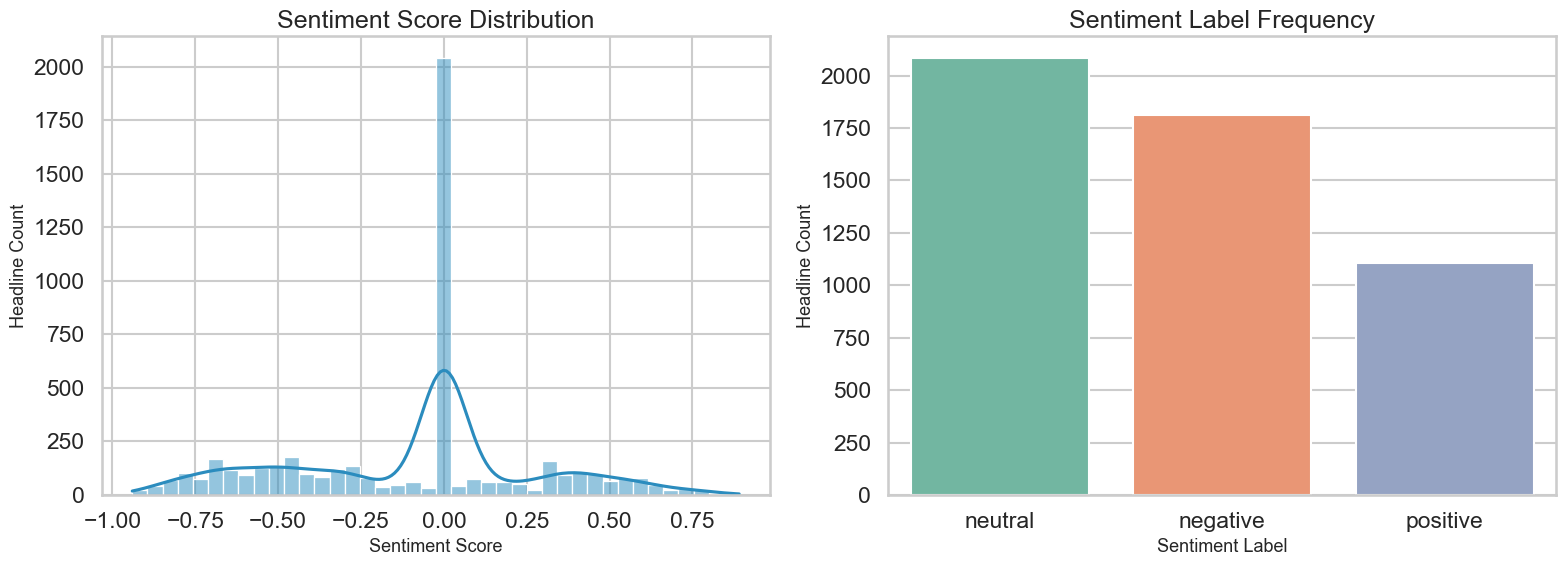

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df['sentiment_score'], bins=40, kde=True, color='#2b8cbe', ax=axes[0])
axes[0].set_title('Sentiment Score Distribution')
axes[0].set_xlabel('Sentiment Score')
axes[0].set_ylabel('Headline Count')

label_order = df['sentiment_label'].value_counts().index
sns.countplot(data=df, x='sentiment_label', order=label_order, palette='Set2', ax=axes[1])
axes[1].set_title('Sentiment Label Frequency')
axes[1].set_xlabel('Sentiment Label')
axes[1].set_ylabel('Headline Count')

plt.tight_layout()
plt.show()

C:\Users\umer\AppData\Local\Temp\ipykernel_13456\2314388823.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_top_cat, y='category', order=top_categories, palette='Blues_r', ax=axes[0])
C:\Users\umer\AppData\Local\Temp\ipykernel_13456\2314388823.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_cat, x='sentiment_score', y='category', order=top_categories, palette='Set3', ax=axes[1])


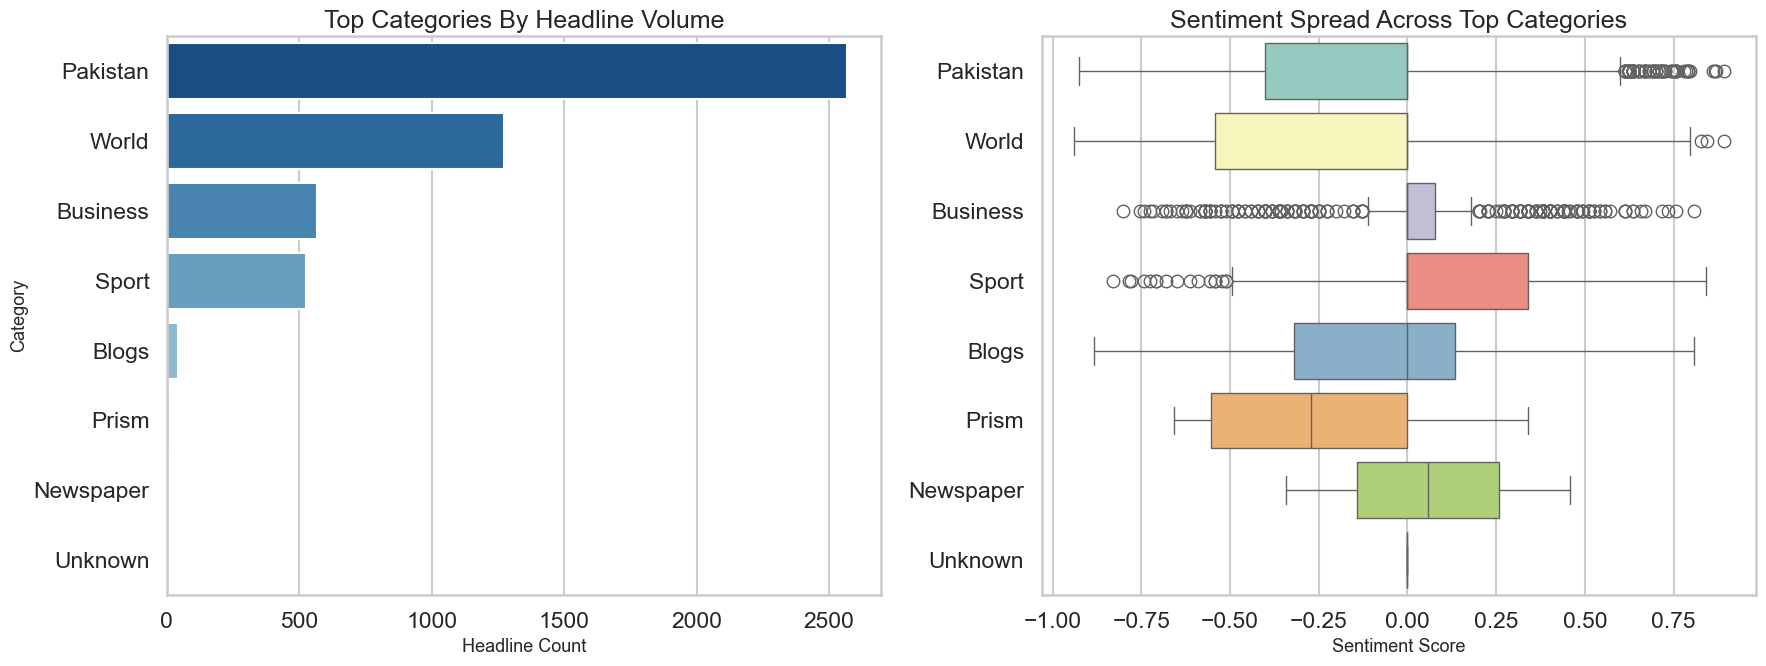

In [76]:
top_categories = df['category'].value_counts().head(8).index
df_top_cat = df[df['category'].isin(top_categories)].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.countplot(data=df_top_cat, y='category', order=top_categories, palette='Blues_r', ax=axes[0])
axes[0].set_title('Top Categories By Headline Volume')
axes[0].set_xlabel('Headline Count')
axes[0].set_ylabel('Category')

sns.boxplot(data=df_top_cat, x='sentiment_score', y='category', order=top_categories, palette='Set3', ax=axes[1])
axes[1].set_title('Sentiment Spread Across Top Categories')
axes[1].set_xlabel('Sentiment Score')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Temporal Trends

In [77]:
monthly = (
    df.dropna(subset=['published_at'])
      .assign(month=lambda x: x['published_at'].dt.to_period('M').dt.to_timestamp())
      .groupby(['month', 'sentiment_label'], as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)

fig = px.area(
    monthly,
    x='month',
    y='count',
    color='sentiment_label',
    title='Monthly Headline Sentiment Mix',
    labels={'month': 'Month', 'count': 'Headline Count', 'sentiment_label': 'Sentiment'}
)
fig.update_layout(template='plotly_white', legend_title_text='Sentiment')
fig.show()

## Topic Modeling Views

In [78]:
topic_counts = (
    df['topic_name']
    .value_counts()
    .rename_axis('topic_name')
    .reset_index(name='count')
)

fig = px.bar(
    topic_counts,
    x='count',
    y='topic_name',
    orientation='h',
    color='count',
    color_continuous_scale='Tealgrn',
    title='Dominant Topic Distribution',
    labels={'count': 'Headline Count', 'topic_name': 'Topic'}
)
fig.update_layout(template='plotly_white', yaxis={'categoryorder': 'total ascending'})
fig.show()

In [79]:
topic_sentiment = (
    df.groupby(['topic_name', 'sentiment_label'], as_index=False)
      .size()
      .rename(columns={'size': 'count'})
)

fig = px.bar(
    topic_sentiment,
    x='topic_name',
    y='count',
    color='sentiment_label',
    barmode='group',
    title='Sentiment Composition By Topic',
    labels={'topic_name': 'Topic', 'count': 'Headline Count', 'sentiment_label': 'Sentiment'}
)
fig.update_layout(template='plotly_white', xaxis_tickangle=-35)
fig.show()

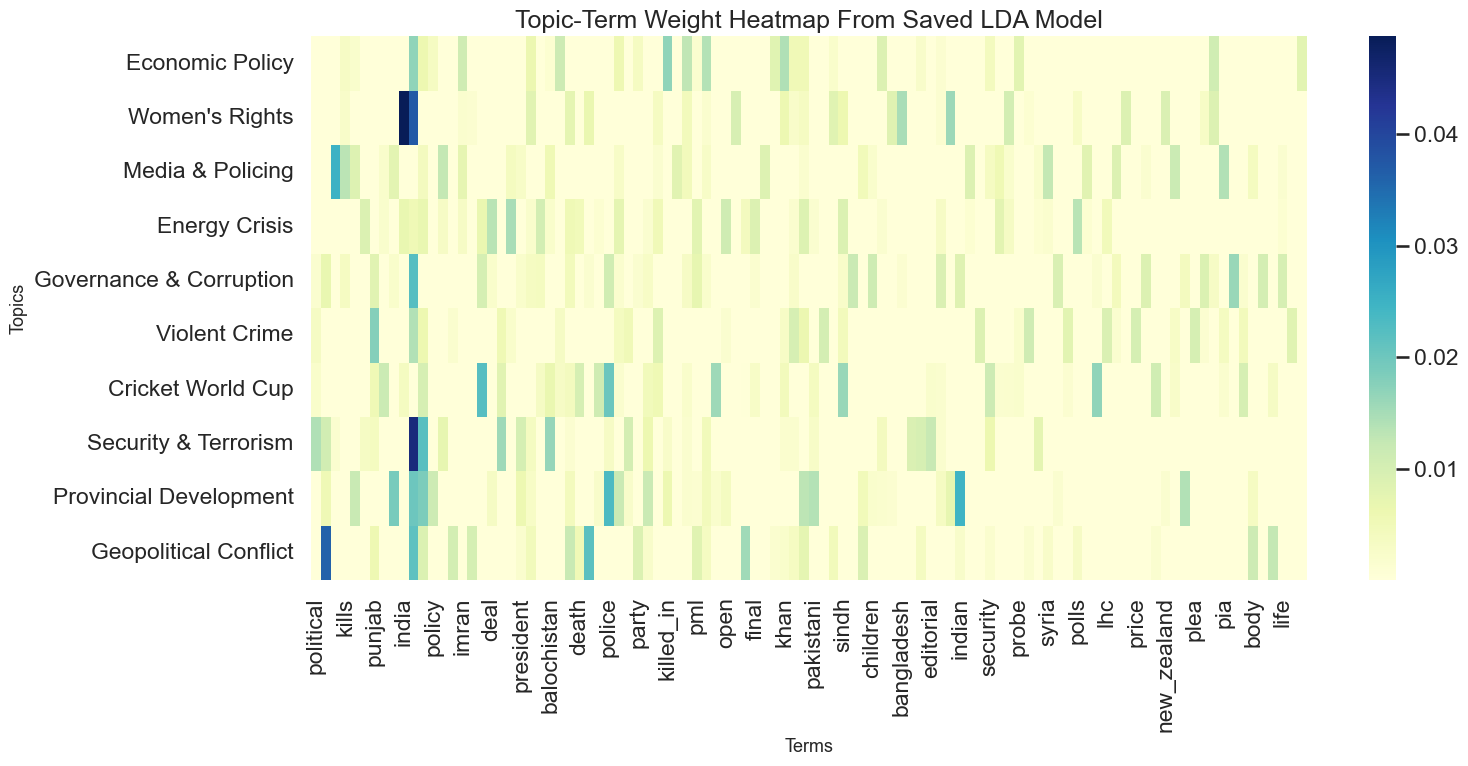

pyLDAvis skipped: no serialized corpus artifact found in existing outputs.


In [80]:
lda_model = gensim.models.LdaMulticore.load(str(model_path))
dictionary = corpora.Dictionary.load(str(dictionary_path))

topic_term_matrix = lda_model.get_topics()
topic_labels = [topic_mapping.get(i, f'Topic {i}') for i in range(lda_model.num_topics)]
top_terms_per_topic = 12
top_term_indices = np.unique(np.argsort(topic_term_matrix, axis=1)[:, -top_terms_per_topic:].ravel())
heatmap_df = pd.DataFrame(
    topic_term_matrix[:, top_term_indices],
    index=topic_labels,
    columns=[dictionary[i] for i in top_term_indices]
)

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_df, cmap='YlGnBu')
plt.title('Topic-Term Weight Heatmap From Saved LDA Model')
plt.xlabel('Terms')
plt.ylabel('Topics')
plt.tight_layout()
plt.show()

corpus_candidates = [
    PROJECT_ROOT / 'models' / 'lda_corpus.mm',
    PROJECT_ROOT / 'data' / 'processed' / 'lda_corpus.mm'
]
existing_corpus = next((p for p in corpus_candidates if p.exists()), None)
if existing_corpus is not None:
    corpus = corpora.MmCorpus(str(existing_corpus))
    lda_vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary, sort_topics=False)
    pyLDAvis.display(lda_vis)
else:
    print('pyLDAvis skipped: no serialized corpus artifact found in existing outputs.')

## Word Clouds For Text Insights

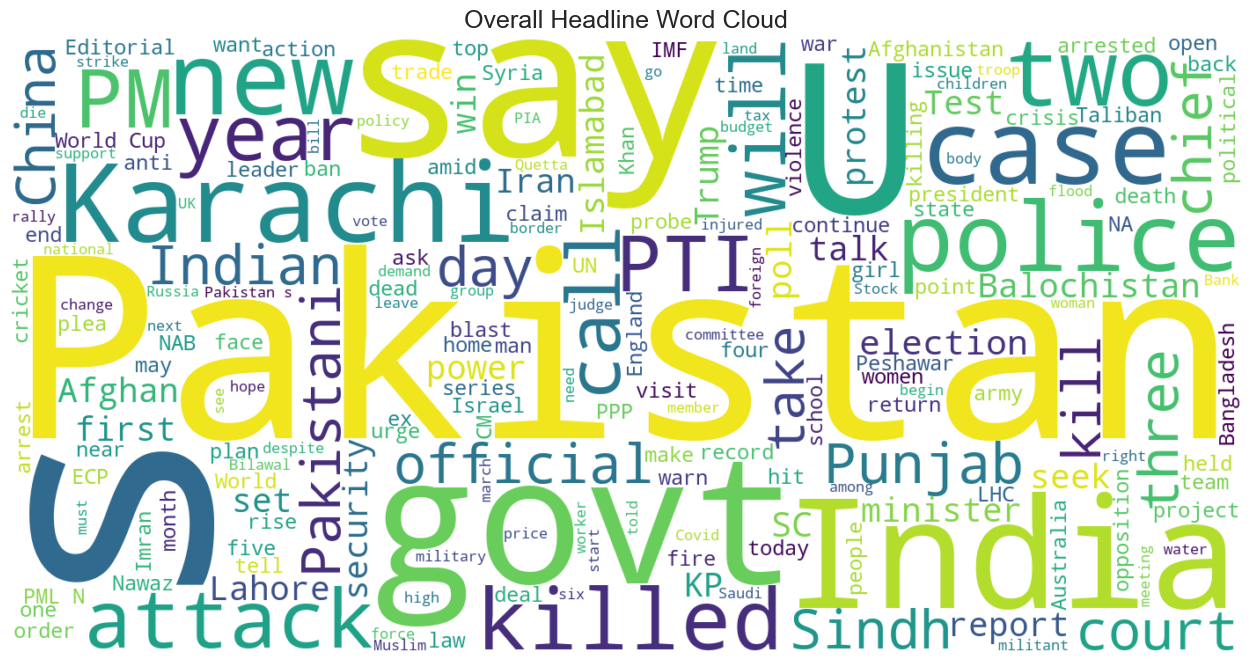

In [81]:
all_text = ' '.join(df['headline'].fillna('').astype(str).tolist())
wc_all = WordCloud(width=1400, height=700, background_color='white', colormap='viridis').generate(all_text)

plt.figure(figsize=(16, 8))
plt.imshow(wc_all, interpolation='bilinear')
plt.axis('off')
plt.title('Overall Headline Word Cloud')
plt.show()

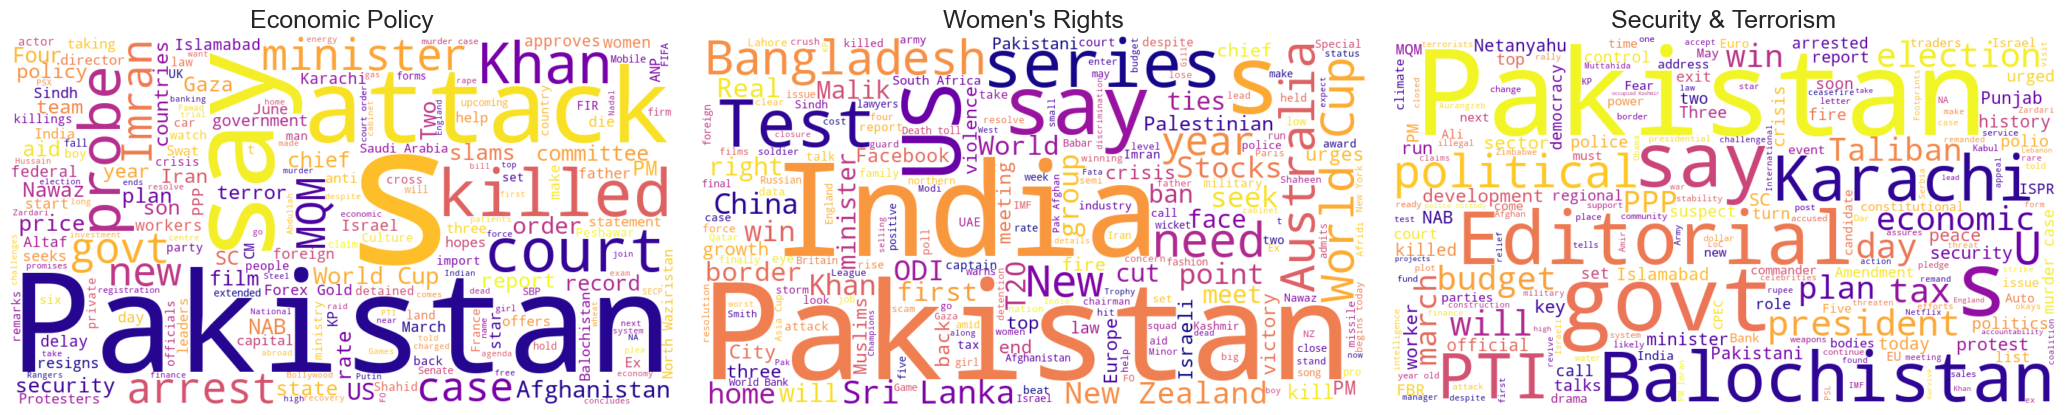

In [82]:
top_topic_ids = df['dominant_topic'].value_counts().head(3).index.tolist()
fig, axes = plt.subplots(1, len(top_topic_ids), figsize=(7 * len(top_topic_ids), 6))
if len(top_topic_ids) == 1:
    axes = [axes]

for ax, topic_id in zip(axes, top_topic_ids):
    topic_text = ' '.join(df.loc[df['dominant_topic'] == topic_id, 'headline'].fillna('').astype(str).tolist())
    wc = WordCloud(width=900, height=500, background_color='white', colormap='plasma').generate(topic_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(topic_mapping.get(int(topic_id), f'Topic {topic_id}'))

plt.tight_layout()
plt.show()

## Entity Network Visualization

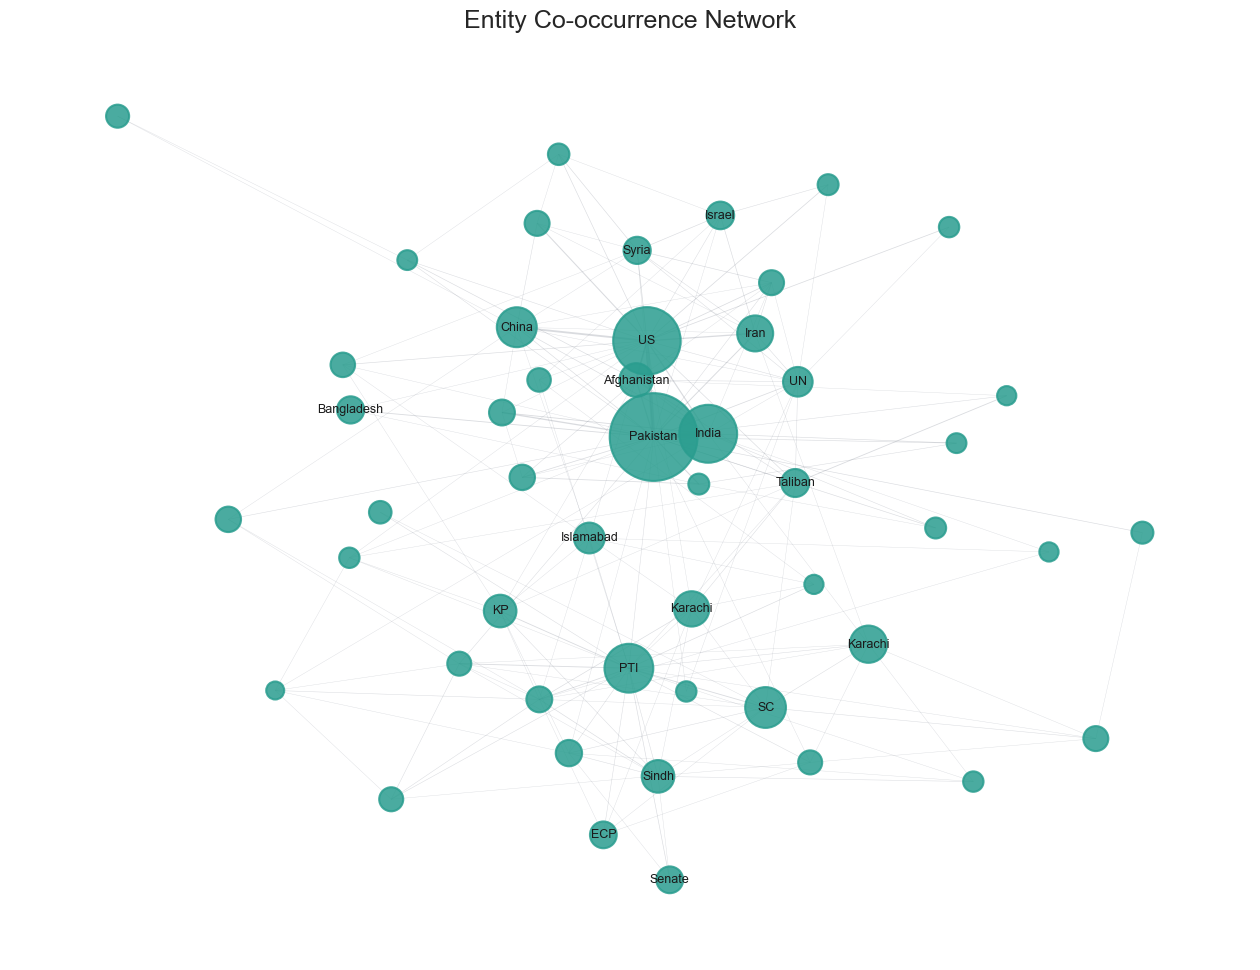

In [83]:
G = nx.Graph()
for node in network_data.get('nodes', []):
    G.add_node(node['id'], label=node.get('name', node['id']), size=node.get('value', 1), group=node.get('group', 'UNK'))
for link in network_data.get('links', []):
    G.add_edge(link['source'], link['target'], weight=link.get('value', 1))

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, seed=42, k=0.55)
node_sizes = [G.nodes[n]['size'] * 12 for n in G.nodes()]
edge_widths = [0.2 + G[u][v]['weight'] * 0.08 for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, alpha=0.25, width=edge_widths, edge_color='#6b7280')
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#2a9d8f', alpha=0.85)
label_nodes = sorted(G.nodes(), key=lambda n: G.nodes[n]['size'], reverse=True)[:20]
labels = {n: G.nodes[n]['label'] for n in label_nodes}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)
plt.title('Entity Co-occurrence Network')
plt.axis('off')
plt.show()

In [84]:
import networkx as nx
import plotly.graph_objects as go

pos = nx.spring_layout(G, seed=42, k=2.0, iterations=150)

edge_x = []
edge_y = []

for u, v, d in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode='lines',
    line=dict(width=0.4, color='#cbd5e1'),
    hoverinfo='none'
)

node_x = []
node_y = []
node_text = []
node_size = []

for n in G.nodes():
    x, y = pos[n]
    node_x.append(x)
    node_y.append(y)

    node_text.append(
        f"{G.nodes[n].get('label', n)}<br>"
        f"Freq: {G.nodes[n].get('size', 1)}"
    )

    node_size.append(3 + G.nodes[n].get('size', 1) * 0.25)

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers',
    text=node_text,
    hoverinfo='text',
    marker=dict(
        size=node_size,
        color=node_size,
        colorscale='Teal',
        showscale=True,
        opacity=0.8,
        line=dict(width=0.2, color='white')
    )
)

fig = go.Figure(data=[edge_trace, node_trace])

fig.update_layout(
    title='Entity Network',
    template='plotly_white',
    showlegend=False,
    width=1300,
    height=900,
    margin=dict(l=10, r=10, t=50, b=10),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
)

fig.show()

In [85]:
import numpy as np
import pandas as pd
import plotly.express as px

false_positive_names = {'Brexit', 'T20', 'Haj', 'UN', 'EU', 'US'}

person_entities = []

for entities in df['extracted_entities']:
    if isinstance(entities, (list, tuple, np.ndarray)):
        for ent in entities:
            if isinstance(ent, str):
                raw = ent.strip()

                if raw.endswith(')') and '(' in raw:
                    name, label = raw.rsplit('(', 1)
                    label = label.replace(')', '').strip().upper()

                    if label in {'PERSON', 'PER'}:
                        cleaned_name = name.strip()

                        if (
                            cleaned_name
                            and cleaned_name not in false_positive_names
                            and not any(ch.isdigit() for ch in cleaned_name)
                        ):
                            tokens = cleaned_name.split()

                            if len(tokens) > 1 or cleaned_name.istitle():
                                person_entities.append(cleaned_name)

top_n = 20

person_freq = (
    pd.Series(person_entities, name='person')
    .value_counts()
    .head(top_n)
    .rename_axis('person')
    .reset_index(name='count')
)

if person_freq.empty:
    print('No PERSON entities are present in the current processed dataset.')
else:
    display(person_freq)

    fig = px.bar(
        person_freq.sort_values('count', ascending=True),
        x='count',
        y='person',
        orientation='h',
        title=f'Top {top_n} Most Frequent Person Entities',
        labels={'count': 'Mentions', 'person': 'Person'}
    )

    fig.update_layout(
        template='plotly_white',
        height=600 + (top_n * 20),
        margin=dict(l=220, r=50, t=80, b=50)
    )

    fig.update_yaxes(automargin=True)

    fig.show()

,person,count
0,Khan,18
1,Zardari,14
2,Netanyahu,10
3,Shahbaz,9
4,Obama,9
5,Trump,9
6,Sharif,8
7,Putin,7
8,Karzai,6
9,Erdogan,6


## Interpretation Prompts

Use the visuals above to extract concise storylines for topic prevalence, sentiment shifts, and entity relationships over time. Focus on persistent trends, sudden inflection points, and the strongest category-topic-sentiment combinations.